In [132]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

In [133]:
sys.path.append('..')

In [134]:
from vital.metrics import get_survival_metrics, get_risk_metrics, get_censoring_dist, include_exam_and_determine_label

In [135]:
# Import json file
with open("/tank-1/data/NLST/json/train_our_updated.json") as f:
    train_data = json.load(f)

with open("/tank-1/data/checkpoints/lung_survival/predictions_cosmic-field-201.json") as f:
    data = json.load(f)


In [136]:
censoring_dist = get_censoring_dist(train_data)

In [137]:
censoring_dist

{'0': 0.9860950173812297,
 '1': 0.9764641732812178,
 '2': 0.9682088843711711,
 '3': 0.9618680525189961,
 '4': 0.9563014097865051,
 '5': 0.9507666066496202}

In [138]:
df = pd.DataFrame(data)
df.head()

,cancer_risk,gold,censors,pid,study,series,screen_timepoint,institution,cancer_laterality,y,time_at_event,y_seq,y_mask
0,"[0.05602938309311867, 0.05602938309311867, 0.0...",0,5,100005,1.2.840.113654.2.55.15354675073554904449223965...,1.2.840.113654.2.55.33065633377443331729120546...,0,A,"[4, False]",0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]"
1,"[0.05399883911013603, 0.05399883911013603, 0.0...",0,5,100005,1.2.840.113654.2.55.10251457513072085864761297...,1.2.840.113654.2.55.17324290215190661437113320...,1,A,"[4, False]",0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]"
2,"[0.10669060051441193, 0.10669060051441193, 0.1...",0,4,100005,1.2.840.113654.2.55.10940192540799808329280702...,1.2.840.113654.2.55.21247452796009259375851140...,2,A,"[4, False]",0,4,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0]"
3,"[0.6216557621955872, 0.6216557621955872, 0.621...",1,1,100012,1.2.840.113654.2.55.23803494144550801138646327...,1.2.840.113654.2.55.24023112856488152536348979...,0,A,"[4, False]",1,1,"[0, 1, 1, 1, 1, 1]","[1, 1, 0, 0, 0, 0]"
4,"[0.6606104373931885, 0.6606104373931885, 0.660...",1,0,100012,1.2.840.113654.2.55.38321092839390108338558865...,1.2.840.113654.2.55.50761756412482430061802871...,1,A,"[4, False]",1,0,"[1, 1, 1, 1, 1, 1]","[1, 0, 0, 0, 0, 0]"


In [139]:
probs = np.stack(df['cancer_risk'])
golds = np.stack(df['gold'])
censors = np.stack(df['censors'])
y = np.stack(df['y'])

In [140]:
get_survival_metrics(censors, probs, golds, censoring_dist, max_followup=6, mode="test")

{'test/1_year_auc': 0.9112729293039693,
 'test/1_year_apscore': 0.3896984990220346,
 'test/1_year_prauc': 0.3848187741295597,
 'test/2_year_auc': 0.8708345392927525,
 'test/2_year_apscore': 0.3396376241535347,
 'test/2_year_prauc': 0.3361666424700245,
 'test/3_year_auc': 0.8263619650262944,
 'test/3_year_apscore': 0.29841236755113654,
 'test/3_year_prauc': 0.2957407380199069,
 'test/4_year_auc': 0.8027711498027357,
 'test/4_year_apscore': 0.2808782210403722,
 'test/4_year_prauc': 0.2786446622926632,
 'test/5_year_auc': 0.7902223287618162,
 'test/5_year_apscore': 0.29105661955658807,
 'test/5_year_prauc': 0.28977825358210146,
 'test/6_year_auc': 0.7883375346754609,
 'test/6_year_apscore': 0.3526049637007819,
 'test/6_year_prauc': 0.35162119455954083,
 'test/c_index': 0.7851012829049132}

In [141]:
get_risk_metrics(censors, probs, golds, max_followup=6, mode="test")

/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


{'test/1_year_risk_auc': nan,
 'test/1_year_risk_apscore': 0.0,
 'test/1_year_risk_prauc': 0.5,
 'test/2_year_risk_auc': 0.8006244837067084,
 'test/2_year_risk_apscore': 0.05009772500397204,
 'test/2_year_risk_prauc': 0.04610137113357994,
 'test/3_year_risk_auc': 0.7524902794318298,
 'test/3_year_risk_apscore': 0.06274456773263064,
 'test/3_year_risk_prauc': 0.06016961238123941,
 'test/4_year_risk_auc': 0.7381795143341835,
 'test/4_year_risk_apscore': 0.07755801514605759,
 'test/4_year_risk_prauc': 0.07549553105940807,
 'test/5_year_risk_auc': 0.7357251399904243,
 'test/5_year_risk_apscore': 0.10194985088490985,
 'test/5_year_risk_prauc': 0.10007026350307005,
 'test/6_year_risk_auc': 0.7390366779893898,
 'test/6_year_risk_apscore': 0.15308326462807265,
 'test/6_year_risk_prauc': 0.15083685902120286}

# TPR at x FPR and Precision at x Recall

In [142]:
def get_probs_and_golds(probs, censor_times, golds, followup, fup_lower_bound=-1):
    probs_for_eval = []
    golds_for_eval = []
    for prob_arr, censor_time, gold in zip(probs, censor_times, golds):
        include, label = include_exam_and_determine_label(censor_time, gold, followup, fup_lower_bound)
        if include:
            probs_for_eval.append(prob_arr[followup])
            golds_for_eval.append(label)
    return probs_for_eval, golds_for_eval



# FUP lower bound
## Survival
default value = -1

## Risk
value = 0

In [143]:
def get_tpr_at_fpr(probs, censors, golds, fpr_target=0.1, fup_lower_bound=-1):
    tpr_list = []
    for i in range(6):
        p, g = get_probs_and_golds(probs, censors, golds, i, fup_lower_bound)
        # Get TPR at x FPR
        fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
        tpr_val = tpr[np.where(fpr <= fpr_target)[0][-1]]
        tpr_list.append(tpr_val)
    return tpr_list

def get_precision_at_recall(probs, censors, golds, recall_target=0.8):
    precision_list = []
    for i in range(6):
        p, g = get_probs_and_golds(probs, censors, golds, i,    fup_lower_bound=-1)
        # Get precision at x recall
        precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
        precision_val = precision[np.where(recall >= recall_target)[0][-1]]
        precision_list.append(precision_val)
    return precision_list
    

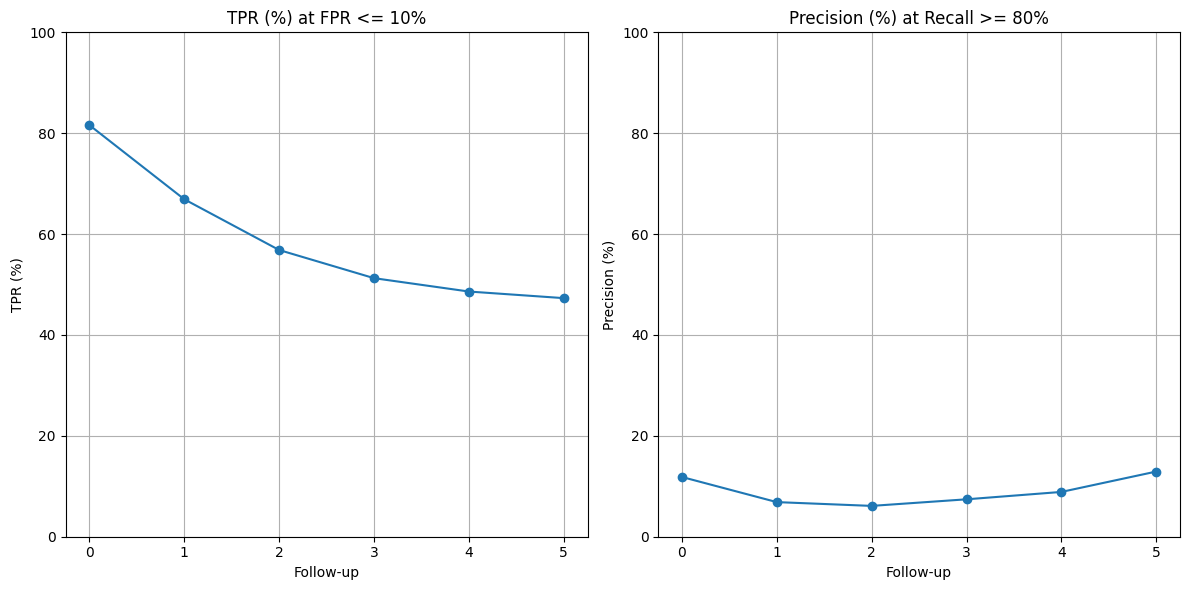

TPR (%) values at FPR <= 10.0%: [81.60919540229885, 66.90647482014388, 56.84210526315789, 51.26050420168067, 48.61111111111111, 47.3015873015873]
Precision (%) values at Recall >= 80.0%: [11.844331641285956, 6.862745098039216, 6.11178126256534, 7.41747572815534, 8.881199538638986, 12.923076923076923]


In [144]:
# Plot tprs at fpr and precisions at recall grapphs. Two different graphs. for followup 0 to 5. Add grids to the plots.

import matplotlib.pyplot as plt

fpr_target = 0.1
recall_target = 0.8

tpr_values = get_tpr_at_fpr(probs, censors, golds, fpr_target)
precision_values = get_precision_at_recall(probs, censors, golds, recall_target)

# Convert decimals to percentages
tpr_percent = [v * 100 if v is not None else None for v in tpr_values]
precision_percent = [v * 100 if v is not None else None for v in precision_values]

# Plot TPR at FPR
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(6), tpr_percent, marker='o')
plt.title(f'TPR (%) at FPR <= {fpr_target*100:.0f}%')
plt.xlabel('Follow-up')
plt.ylabel('TPR (%)')
plt.xticks(range(6))
plt.ylim(0, 100)
plt.grid()  # Add grid to first plot

# Plot Precision at Recall
plt.subplot(1, 2, 2)
plt.plot(range(6), precision_percent, marker='o')
plt.title(f'Precision (%) at Recall >= {recall_target*100:.0f}%')
plt.xlabel('Follow-up')
plt.ylabel('Precision (%)')
plt.xticks(range(6))
plt.ylim(0, 100)
plt.grid()  # Add grid to second plot

plt.tight_layout()
plt.show()

print("TPR (%) values at FPR <= {}%: {}".format(fpr_target*100, tpr_percent))
print("Precision (%) values at Recall >= {}%: {}".format(recall_target*100, precision_percent))

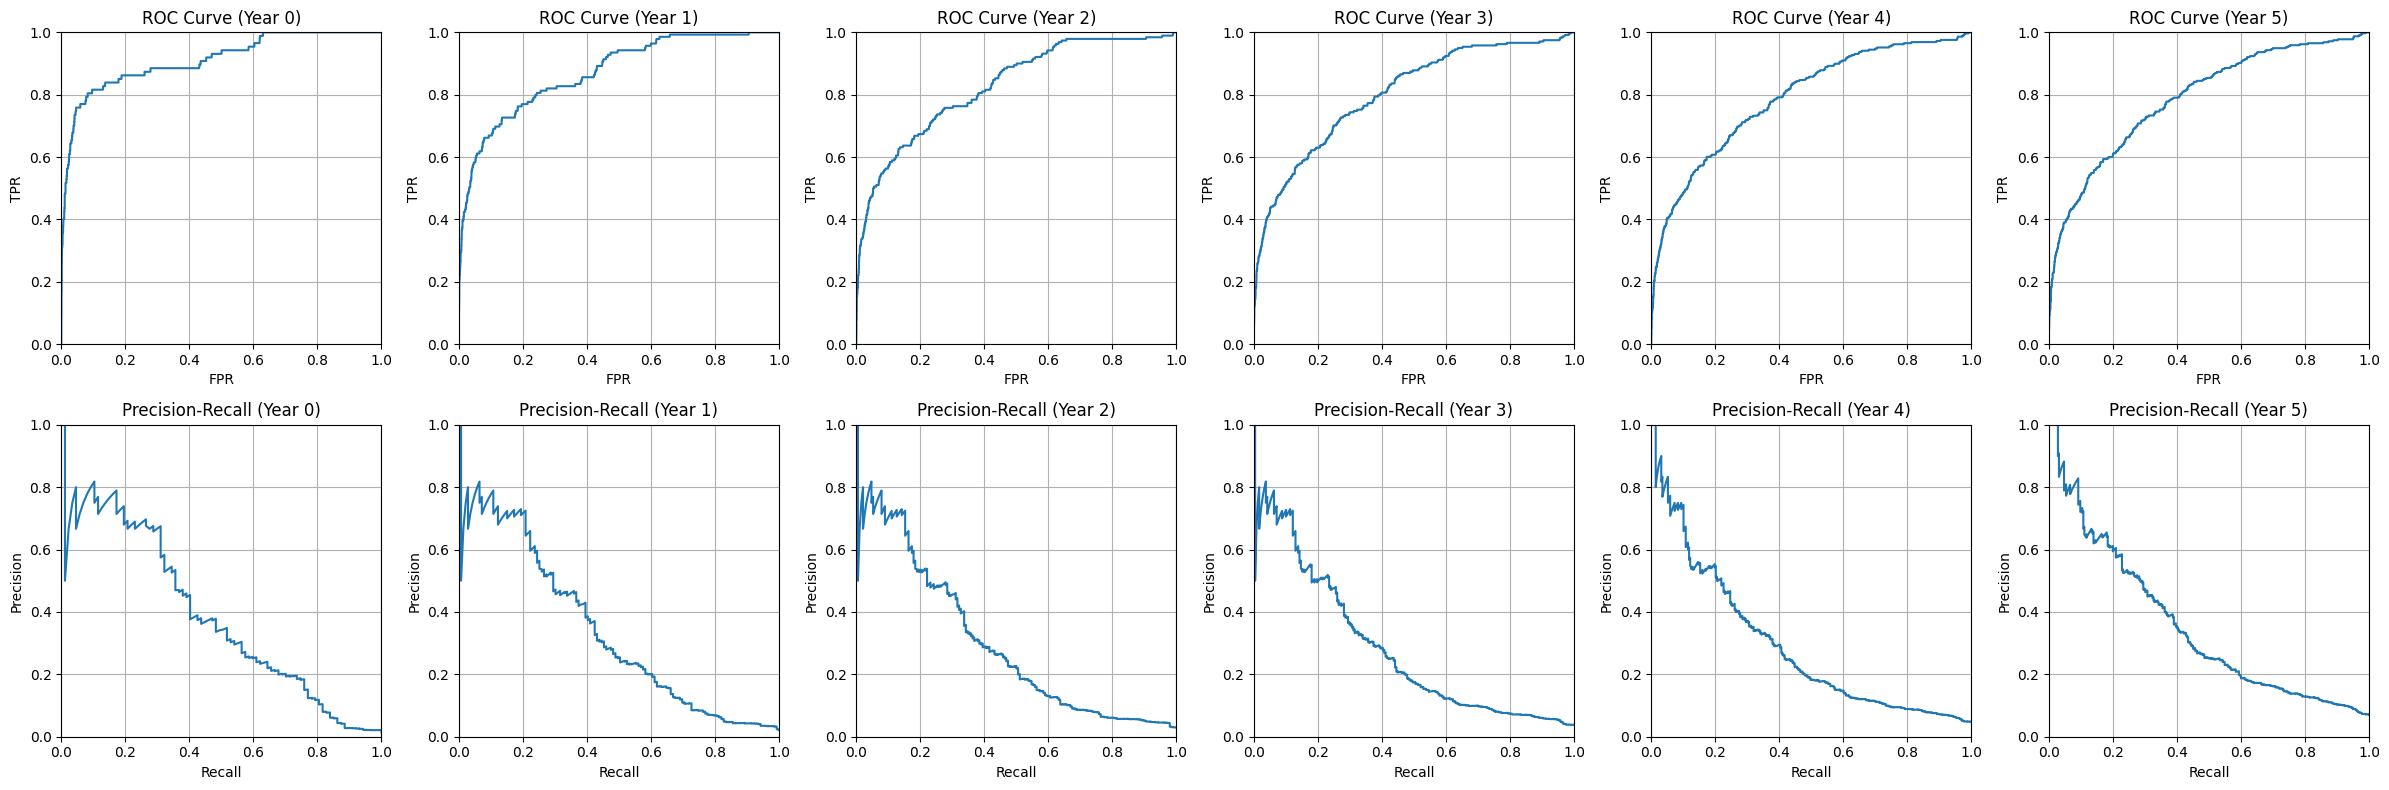

In [145]:
# Plot ROC and Precision-Recall curves for all followup years
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for i in range(6):
    # Get data for this followup year
    p, g = get_probs_and_golds(probs, censors, golds, i)
    # ROC curve
    fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
    axes[0, i].plot(fpr, tpr, label=f'Year {i}')
    axes[0, i].set_title(f'ROC Curve (Year {i})')
    axes[0, i].set_xlabel('FPR')
    axes[0, i].set_ylabel('TPR')
    axes[0, i].set_xlim(0, 1)
    axes[0, i].set_ylim(0, 1)
    axes[0, i].grid()
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
    axes[1, i].plot(recall, precision, label=f'Year {i}')
    axes[1, i].set_title(f'Precision-Recall (Year {i})')
    axes[1, i].set_xlabel('Recall')
    axes[1, i].set_ylabel('Precision')
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].grid()
plt.tight_layout()
plt.show()

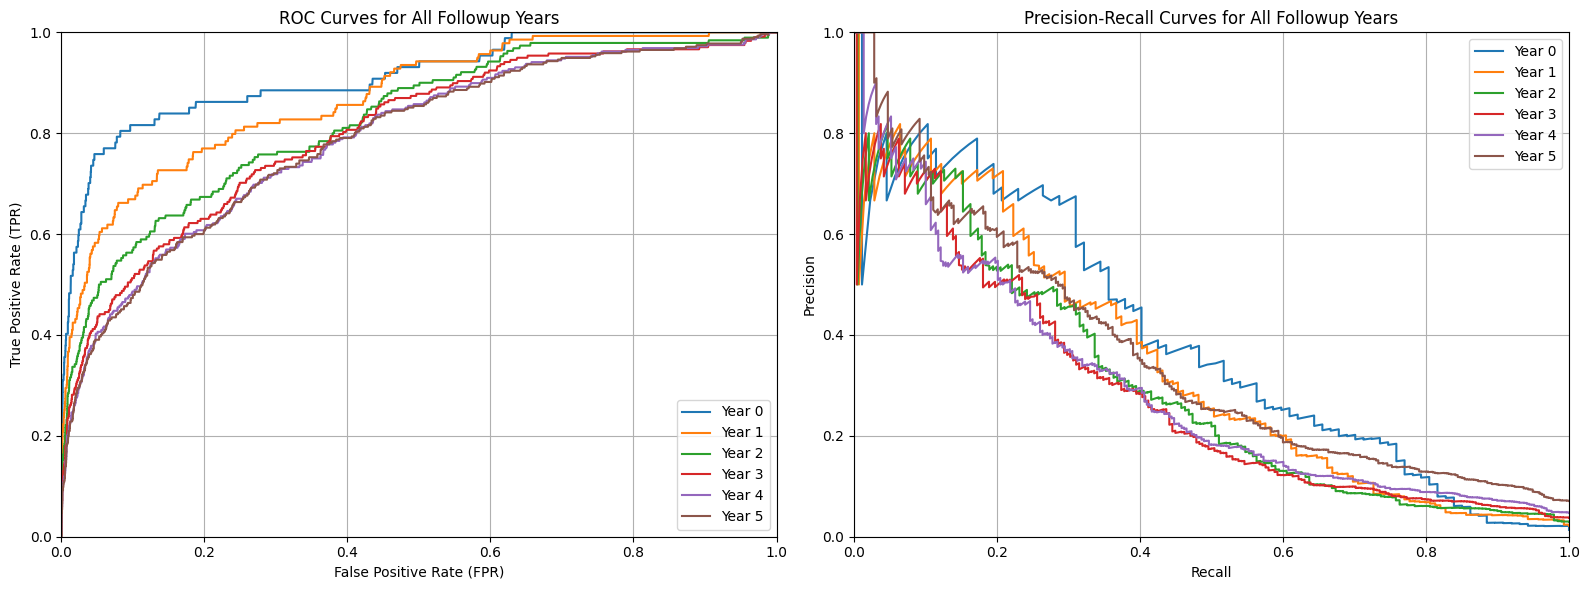

In [146]:
# Plot ROC and Precision-Recall curves for all followup years side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i in range(6):
    p, g = get_probs_and_golds(probs, censors, golds, i)
    fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
    axes[0].plot(fpr, tpr, label=f'Year {i}')
axes[0].set_title('ROC Curves for All Followup Years')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid()
for i in range(6):
    p, g = get_probs_and_golds(probs, censors, golds, i)
    precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
    axes[1].plot(recall, precision, label=f'Year {i}')
axes[1].set_title('Precision-Recall Curves for All Followup Years')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid()
plt.tight_layout()
plt.show()

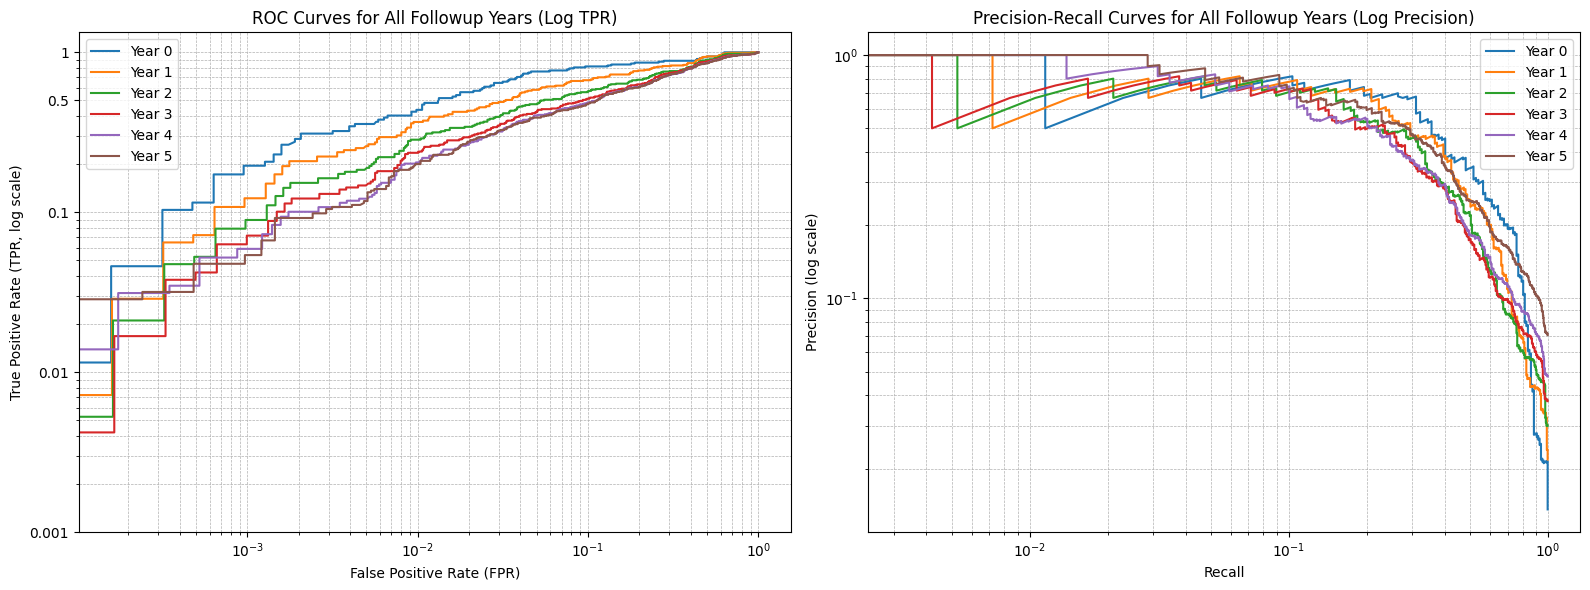

In [147]:
# Plot ROC and Precision-Recall curves for all followup years side by side with log-scaled y-axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i in range(6):
    p, g = get_probs_and_golds(probs, censors, golds, i)
    fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
    axes[0].plot(fpr, tpr, label=f'Year {i}')
axes[0].set_title('ROC Curves for All Followup Years (Log TPR)')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR, log scale)')
# axes[0].set_xlim(0, 1)
# axes[0].set_ylim(1e-1, 1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(which='both', linestyle='--', linewidth=0.5)
axes[0].set_yticks([0.001, 0.01, 0.1, 0.5, 1])
axes[0].set_yticklabels(['0.001', '0.01', '0.1', '0.5', '1'])
for i in range(6):
    p, g = get_probs_and_golds(probs, censors, golds, i)
    precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
    axes[1].plot(recall, precision, label=f'Year {i}')
axes[1].set_title('Precision-Recall Curves for All Followup Years (Log Precision)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision (log scale)')
# axes[1].set_xlim(0, 1)
# axes[1].set_ylim(1e-3, 1)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(which='both', linestyle='--', linewidth=0.5)
# axes[1].set_yticks([0.001, 0.01, 0.1, 0.5, 1])
# axes[1].set_yticklabels(['0.001', '0.01', '0.1', '0.5', '1'])
plt.tight_layout()
plt.show()